In [72]:
from dotenv import load_dotenv
from langchain_google_genai import ChatGoogleGenerativeAI
import os
from langchain.tools import tool
load_dotenv()

if os.environ['GOOGLE_API_KEY'] == "":
    raise ValueError("GOOGLE_API_KEY is not set in the .env file.")
else:
    print("GOOGLE_API_KEY is set correctly.")

GOOGLE_API_KEY is set correctly.


In [73]:
llm = ChatGoogleGenerativeAI(model="gemini-3.1-flash-lite",)
llm

ChatGoogleGenerativeAI(metadata={'lc_versions': {'langchain-core': '1.4.9', 'langchain': '1.3.13', 'langchain-google-genai': '4.2.6'}}, output_version=None, profile={'name': 'Gemini 3.1 Flash Lite', 'release_date': '2026-05-07', 'last_updated': '2026-05-07', 'open_weights': False, 'max_input_tokens': 1048576, 'max_output_tokens': 65536, 'text_inputs': True, 'image_inputs': True, 'audio_inputs': True, 'pdf_inputs': True, 'video_inputs': True, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'structured_output': True, 'attachment': True, 'temperature': True, 'image_url_inputs': True, 'image_tool_message': True, 'tool_choice': True}, google_api_key=SecretStr('**********'), location=None, model='gemini-3.1-flash-lite', temperature=1.0, client=<google.genai.client.Client object at 0x0000028E4ED47E50>, default_metadata=(), model_kwargs={})

In [74]:
from pydantic import BaseModel, Field
from typing import List, TypedDict, Literal

class llm_schema(BaseModel):
    funny_flag: Literal["funny", "not funny"] = Field(..., description="Indicator of whether the joke is funny or not.")
    feedback: str = Field(..., description="Feedback on the joke.")

llm_with_schema = llm.with_structured_output(llm_schema)

In [75]:
class graph_schema(TypedDict):
    topic: str
    joke: str
    funny_flag: str
    feedback: str
    iterations: int

In [76]:
from langchain_core.prompts import ChatPromptTemplate

def generate_node(state: graph_schema) -> graph_schema:
    
    topic = state["topic"]
    feedback = state["feedback"]
    joke = state["joke"]

    if feedback:
        prompt = ChatPromptTemplate.from_messages(
            [
                (
                    "system",
                    """
                        You are a professional comedian.

                        Your task is to improve jokes based on feedback.

                        Rules:
                        - Return ONLY the improved joke.
                        - Do not explain your reasoning.
                        - Do not provide multiple options.
                        - Do not include any headings or bullet points.
                        - Output exactly one joke.
                    """
                ),
                (
                    "user",
                    """
                        Original joke:

                        {joke}

                        Feedback:

                        {feedback}

                        Rewrite the joke.
                    """
                )
            ]
        )

        chain = prompt | llm

        response = chain.invoke(
            {
                "joke": joke,
                "feedback": feedback
            }
        )
    else:
        prompt = ChatPromptTemplate.from_messages(
            [
                (
                    "system",
                    """
                        You are a professional comedian. Write a short, original joke.
                        Return ONLY the joke.
                    """
                ),
                (
                    "user",
                    "Write a joke about {topic}. Only output the joke."
                )
            ]
        )

        chain = prompt | llm

        response = chain.invoke({"topic": topic})

    state["joke"] = response.content[0]["text"]
    return state

In [77]:
def evaluate_node(state: graph_schema) -> graph_schema:

    joke = state["joke"]
    iterations = state["iterations"]

    prompt = ChatPromptTemplate.from_messages(
        [
            ("system", "You are a comedy critic. Your job is to evaluate the following joke and provide feedback on how to make it funnier."),
            ("user", "Evaluate the following joke:\n\n{joke}\n\nRespond with 'funny' or 'not funny' and provide feedback if you chose 'not_funny'." )
        ]
    )

    chain = prompt | llm_with_schema
    response = chain.invoke({"joke": joke})

    state["funny_flag"] = response.funny_flag
    state["feedback"] = response.feedback
    state["iterations"] = iterations + 1

    return state

In [78]:
def stop_condition(state: graph_schema) -> str:
    iterations = state["iterations"]
    funny_flag = state["funny_flag"]

    if funny_flag == "funny":
        return "end"

    if iterations >= 5:
        return "end"

    return "generate_node"

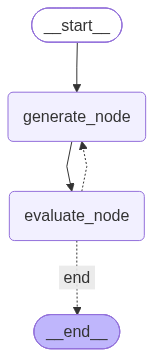

In [79]:
from langgraph.graph import StateGraph, START, END

graph = StateGraph(graph_schema)

graph.add_node("generate_node", generate_node)
graph.add_node("evaluate_node", evaluate_node)

graph.add_edge(START, "generate_node")
graph.add_edge("generate_node", "evaluate_node")
graph.add_conditional_edges("evaluate_node", stop_condition, {"generate_node": "generate_node", "end": END})

ge_graph = graph.compile()

from IPython.display import Image, display
Image(ge_graph.get_graph().draw_mermaid_png())

In [80]:
ge_graph.invoke(
    {
        "topic": "cars",
        "joke": "",
        "funny_flag": "",
        "feedback": "",
        "iterations": 0
    }
)

{'topic': 'cars',
 'joke': 'My car is so old that when I turn on the radio, I get live updates on the Hindenburg disaster.',
 'funny_flag': 'funny',
 'feedback': 'This is a classic example of an exaggeration joke that relies on a specific historical reference to land the punchline. The imagery of an ancient radio pulling signals from 1937 works well because it creates a clear, absurd visual.',
 'iterations': 1}